Stopped training at tree #71


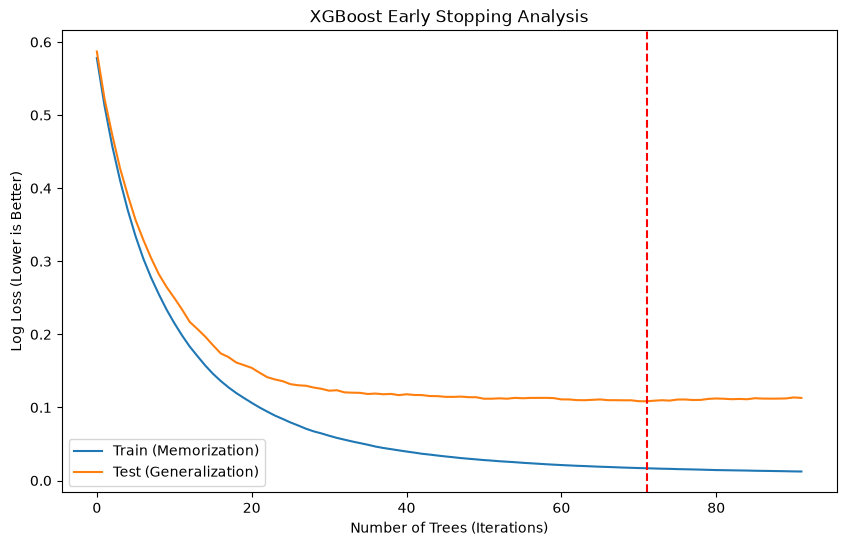

Final Accuracy: 95.61%


In [2]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Setup Data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize Model with Early Stopping
# We set a high n_estimators because early_stopping_rounds will cut it short.
model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    early_stopping_rounds=20,  # Stop if no improvement for 20 rounds
    tree_method="hist",
    random_state=42
)

# 3. Train the model
# We pass both train and test sets to eval_set to record progress for both
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False  # Set to True to see the text logs
)

# 4. Extract results for visualization
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

# 5. Visualize the Training Curves
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_axis, results['validation_0']['logloss'], label='Train (Memorization)')
ax.plot(x_axis, results['validation_1']['logloss'], label='Test (Generalization)')

ax.legend()
plt.ylabel('Log Loss (Lower is Better)')
plt.xlabel('Number of Trees (Iterations)')
plt.title('XGBoost Early Stopping Analysis')

# Highlight the best point
best_iteration = model.best_iteration
plt.axvline(best_iteration, color='r', linestyle='--', label='Early Stop Point')
print(f"Stopped training at tree #{best_iteration}")

plt.show()

# 6. Final Check
y_pred = model.predict(X_test)
print(f"Final Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

In [ ]:
# For a fast, modern CPU-based histogram approach:
model_cpu = xgb.XGBClassifier(
    tree_method="hist",
    n_estimators=100
)

# For a lightning-fast GPU-based approach (if they have an NVIDIA card):
model_gpu = xgb.XGBClassifier(
    tree_method="hist",
    device="cuda",
    n_estimators=100
)

# For the most precise (but slowest) classic approach:
model_exact = xgb.XGBClassifier(
    tree_method="exact",
    n_estimators=100
)